# Sample Quality Control Metadata

This notebook/script imports, harmonizes, and summarizes sample-level quality control metrics generated throughout the bioinformatics pipeline. QC metrics from SeqKit, FastQC/MultiQC, Cutadapt, and DADA2 are merged into a single metadata table that will be used for downstream filtering, visualization, and statistical analyses.

### Library Import

In [1]:

suppressPackageStartupMessages({

########### data import ###########
library(readr)

########### data wrangling ###########
library(tidyverse)
library(tibble)

########### visualization libraries ###########   

library(ggplot2)
library(scales)
library(patchwork)


    

})

### Arguments Piped in with R script Conversion

In [2]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [3]:
INITIAL_QC_DIR <- file.path(PROJECT_DIR, "initial_qc")
DADA2_EXPORT_DIR <- file.path(PROJECT_DIR, "qiime2_results_exported")
READ_QC_DIR <- file.path(INITIAL_QC_DIR, "read_qc")
MULTI_QC_DIR <- file.path(READ_QC_DIR, "multiqc")

# seqkit Tables
#   raw
seqkit_raw_file <- file.path(READ_QC_DIR, "seqkit_stats_raw_fastq.tsv")
#   trimmed
seqkit_trimmed_file <- file.path(READ_QC_DIR, "seqkit_stats_trimmed_fastq.tsv")


multiqc_fastqc_raw_file <- file.path(MULTI_QC_DIR, "raw", "multiqc_data", "multiqc_fastqc.txt")
multiqc_general_raw_file <- file.path(MULTI_QC_DIR, "raw", "multiqc_data", "multiqc_general_stats.txt")
multiqc_fastqc_trimmed_file <- file.path(MULTI_QC_DIR, "trimmed", "multiqc_data", "multiqc_fastqc.txt")
multiqc_general_trimmed_file <- file.path(MULTI_QC_DIR, "trimmed", "multiqc_data", "multiqc_general_stats.txt")
dada2_stats_file <- file.path(DADA2_EXPORT_DIR, "dada2_asv_table_export", "stats.tsv")

# sequencing manifest file - provides the mapping between biological 
#            sample IDs (2BF, 10EU, etc.) and the ENA run IDs (ERR011075, etc.)
manifest_file <- file.path(PROJECT_DIR, "manifest.tsv")

# Main metaata file
metadata_file <- file.path( PROJECT_DIR, paste0(PROJECT_NAME, "_clean_metadata.tsv") )


### Output File Paths

In [4]:
# make report output directories if they don't already exist
REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_QC_DIR <- file.path(FIG_DIR, "qc")
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_QC_DIR, recursive = TRUE, showWarnings = FALSE)



### Read Files

In [5]:
manifest <- read_tsv(manifest_file, show_col_types = FALSE)
seqkit_raw <- read_tsv(seqkit_raw_file, show_col_types = FALSE)
seqkit_trimmed <- read_tsv(seqkit_trimmed_file, show_col_types = FALSE)
fastqc_raw <- read_tsv(multiqc_fastqc_raw_file, show_col_types = FALSE)
fastqc_trimmed <- read_tsv(multiqc_fastqc_trimmed_file, show_col_types = FALSE)

dada2_stats <- read_tsv(
    dada2_stats_file,
    col_types = cols(.default = col_character()), show_col_types = FALSE
    
) |>
    filter(`sample-id` != "#q2:types")  # qiime metadata has #q2:types row

# sample_id <-> ENA run_id
manifest_ids <- manifest |>
    transmute(
        sample_id = `sample-id`,
        run_id = str_extract(basename(`absolute-filepath`), "ERR[0-9]+")
    )


# raw seqkit stats
seqkit_raw_qc <- seqkit_raw |>
    mutate(run_id = str_extract(basename(file), "ERR[0-9]+")) |>
    transmute(
        run_id,
        raw_reads = num_seqs,
        raw_mean_length = avg_len,
        raw_min_length = min_len,
        raw_max_length = max_len,
        raw_Q20_percent = `Q20(%)`,
        raw_Q30_percent = `Q30(%)`,
        raw_mean_quality = AvgQual,
        raw_GC_percent = `GC(%)`,
        raw_N_bases = sum_n
    )


# trimmed seqkit stats. map run_id back to sample_id
seqkit_trimmed_qc <- seqkit_trimmed |>
    mutate(run_id = str_extract(basename(file), "ERR[0-9]+")) |>
    left_join(manifest_ids, by = "run_id") |>
    transmute(
        sample_id, run_id,
        trimmed_reads = num_seqs,
        trimmed_mean_length = avg_len,
        trimmed_min_length = min_len,
        trimmed_max_length = max_len,
        trimmed_Q20_percent = `Q20(%)`,
        trimmed_Q30_percent = `Q30(%)`,
        trimmed_mean_quality = AvgQual,
        trimmed_GC_percent = `GC(%)`,
        trimmed_N_bases = sum_n
    )


# raw fastqc columns to retain
fastqc_raw_qc <- fastqc_raw |>
    transmute(
        run_id = Sample,
        raw_duplication_percent = 100 - total_deduplicated_percentage,
        raw_fastqc_per_base_quality = per_base_sequence_quality,
        raw_fastqc_per_sequence_quality = per_sequence_quality_scores,
        raw_fastqc_length_distribution = sequence_length_distribution,
        raw_fastqc_overrepresented_sequences = overrepresented_sequences,
        raw_fastqc_adapter_content = adapter_content
    )


# trimmed fastqc columns to retain
fastqc_trimmed_qc <- fastqc_trimmed |>
    mutate(run_id = str_extract(Sample, "ERR[0-9]+")) |>
    left_join(manifest_ids, by = "run_id") |>
    transmute(
        sample_id, run_id,
        trimmed_duplication_percent = 100 - total_deduplicated_percentage,
        trimmed_fastqc_per_base_quality = per_base_sequence_quality,
        trimmed_fastqc_per_sequence_quality = per_sequence_quality_scores,
        trimmed_fastqc_length_distribution = sequence_length_distribution,
        trimmed_fastqc_overrepresented_sequences = overrepresented_sequences,
        trimmed_fastqc_adapter_content = adapter_content
    )


# dada2 stats
dada2_qc <- dada2_stats |>
    transmute(
        sample_id = `sample-id`,
        dada2_input_reads = as.numeric(input),
        dada2_filtered_reads = as.numeric(filtered),
        dada2_denoised_reads = as.numeric(denoised),
        dada2_final_reads = as.numeric(`non-chimeric`),
        dada2_filter_retention_percent = as.numeric(`percentage of input passed filter`),
        dada2_final_retention_percent = as.numeric(`percentage of input non-chimeric`)
    )


# sample metadata

metadata <- readr::read_tsv(
    file.path(
        metadata_file
    ), show_col_types = FALSE
) |>
    rename(
        sample_id = `sample-id`,
        run_id = run_accession
    )

In [6]:
metadata

sample_id,run_id,sample_alias,population_group,age_years,sex,reported_ethnicity,antibiotic_history,delivery_mode,clinical_status,⋯,read_count,base_count,mean_fastq_read_length,fastq_bytes,fastq_md5,fastq_ftp,submitted_ftp,sra_avg_spot_length,sra_mbases,sra_mbytes
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
10BF,ERR011058,10BF,BF,6,female,black african,none known,natural childbirth,no malnutrition,⋯,21736,7466281,343.4984,2395763,3433cd6d850f893bc74c0a84a1c80e6e,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011058/ERR011058.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011058/10BF.sff,356,7,20
11BF,ERR011060,11BF,BF,5,male,black african,none known,natural childbirth,no malnutrition,⋯,15278,5142435,336.5908,1570539,9dfaf0ef551f758185f6fb276fe87d08,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011060/ERR011060.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011060/11BF.sff,349,5,14
12BF,ERR011062,12BF,BF,6,male,black african,none known,natural childbirth,no malnutrition,⋯,25647,8802061,343.2004,2726074,3e0c6269a6722cb7cd912bb8995237fd,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011062/ERR011062.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011062/12BF.sff,356,8,24
13BF,ERR011064,13BF,BF,6,male,black african,none known,natural childbirth,no malnutrition,⋯,18242,6304407,345.5985,1991384,726edb66763255292d0c1c2cf403c989,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011064/ERR011064.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011064/13BF.sff,358,6,17
15BF,ERR011066,15BF,BF,6,male,black african,none known,natural childbirth,no malnutrition,⋯,12469,4204668,337.2097,1332507,3936dae65dcffddb127ac49de1f76eab,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011066/ERR011066.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011066/15BF.sff,350,4,11
16BF,ERR011067,16BF,BF,1,female,black african,none known,natural childbirth,no malnutrition,⋯,21594,7282387,337.2412,2423710,3a970237385bb12e6e6022870d630e6a,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011067/ERR011067.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011067/16BF.sff,350,7,20
17BF,ERR011068,17BF,BF,5,female,black african,none known,natural childbirth,no malnutrition,⋯,19432,6687384,344.1429,2059718,a6518e6684df03b0afec1a04618b1bc1,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011068/ERR011068.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011068/17BF.sff,357,6,18
2BF,ERR011075,2BF,BF,5,male,black african,none known,natural childbirth,no malnutrition,⋯,9837,3334139,338.9386,1190973,89eedc068a3401adbc73c8958f2b5c97,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011075/ERR011075.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011075/2BF.sff,352,3,9
3BF,ERR011077,3BF,BF,2,female,black african,none known,natural childbirth,no malnutrition,⋯,16120,5570487,345.5637,1924911,494f094bd72876394537bc1955c07864,ftp.sra.ebi.ac.uk/vol1/fastq/ERR011/ERR011077/ERR011077.fastq.gz,ftp.sra.ebi.ac.uk/vol1/run/ERR011/ERR011077/3BF.sff,359,5,15


### Set Global Parameters

In [7]:

population_colors <- c( # Non-dynamic coloring
  "BF" = "#E16A86",
  "EU" = "#00AD9A"
)

# Dynamically assign colors to values in population_group
population_levels <- unique(metadata$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

population_colors

BF        EU 
"#E16A86" "#00AD9A"

### Join Tables

In [8]:

# join everything together
sample_qc_metadata <- manifest_ids |>
    left_join(seqkit_raw_qc, by = "run_id") |>
    left_join(seqkit_trimmed_qc, by = c("sample_id", "run_id")) |>
    left_join(fastqc_raw_qc, by = "run_id") |>
    left_join(fastqc_trimmed_qc, by = c("sample_id", "run_id")) |>
    left_join(dada2_qc, by = "sample_id") |>
    mutate(
        primer_trim_retention_percent = 100 * trimmed_reads / raw_reads,
        total_pipeline_retention_percent = 100 * dada2_final_reads / raw_reads,
        reads_lost_primer_trimming = raw_reads - trimmed_reads,
        reads_lost_dada2 = dada2_input_reads - dada2_final_reads,
        mean_length_change = trimmed_mean_length - raw_mean_length,
        GC_change = trimmed_GC_percent - raw_GC_percent
    ) |>
    select(
        sample_id, run_id,
        raw_reads, trimmed_reads,
        dada2_input_reads, dada2_filtered_reads, dada2_denoised_reads, dada2_final_reads,
        primer_trim_retention_percent, dada2_filter_retention_percent,
        dada2_final_retention_percent, total_pipeline_retention_percent,
        raw_mean_length, trimmed_mean_length, mean_length_change,
        raw_min_length, raw_max_length, trimmed_min_length, trimmed_max_length,
        raw_Q20_percent, trimmed_Q20_percent,
        raw_Q30_percent, trimmed_Q30_percent,
        raw_mean_quality, trimmed_mean_quality,
        raw_GC_percent, trimmed_GC_percent, GC_change,
        raw_duplication_percent, trimmed_duplication_percent,
        raw_N_bases, trimmed_N_bases,
        raw_fastqc_per_base_quality, trimmed_fastqc_per_base_quality,
        raw_fastqc_per_sequence_quality, trimmed_fastqc_per_sequence_quality,
        raw_fastqc_length_distribution, trimmed_fastqc_length_distribution,
        raw_fastqc_overrepresented_sequences, trimmed_fastqc_overrepresented_sequences,
        raw_fastqc_adapter_content, trimmed_fastqc_adapter_content,
        reads_lost_primer_trimming, reads_lost_dada2
    ) |>
    arrange(
        str_extract(sample_id, "[A-Za-z]+"),
        as.numeric(str_extract(sample_id, "[0-9]+"))
    )




In [9]:
# now do metadata
metadata_join <- metadata |>
    select(
        sample_id, run_id,

        # sample metadata
        population_group,
        age_years,
        sex,
        reported_ethnicity,
        antibiotic_history,
        delivery_mode,
        clinical_status,
        location,
        coordinates,
        diet_description,

        # accession / sequencing metadata
        sample_accession,
        experiment_accession,
        study_accession,
        instrument_platform,
        instrument_model,
        library_layout,

        # QC values reported by ENA / publication
        read_count,
        base_count,
        mean_fastq_read_length,
        fastq_bytes,
        sra_avg_spot_length,
        sra_mbases,
        sra_mbytes
    ) |>
    rename(
        ENA_read_count = read_count,
        ENA_base_count = base_count,
        ENA_mean_fastq_read_length = mean_fastq_read_length,
        ENA_fastq_bytes = fastq_bytes,
        ENA_sra_avg_spot_length = sra_avg_spot_length,
        ENA_sra_mbases = sra_mbases,
        ENA_sra_mbytes = sra_mbytes
    )


# Join everything together again
sample_qc_metadata <- manifest_ids |>
    left_join(metadata_join, by = c("sample_id", "run_id")) |>
    left_join(seqkit_raw_qc, by = "run_id") |>
    left_join(seqkit_trimmed_qc, by = c("sample_id", "run_id")) |>
    left_join(fastqc_raw_qc, by = "run_id") |>
    left_join(fastqc_trimmed_qc, by = c("sample_id", "run_id")) |>
    left_join(dada2_qc, by = "sample_id") |>
    mutate(
        primer_trim_retention_percent = 100 * trimmed_reads / raw_reads,
        total_pipeline_retention_percent = 100 * dada2_final_reads / raw_reads,
        reads_lost_primer_trimming = raw_reads - trimmed_reads,
        reads_lost_dada2 = dada2_input_reads - dada2_final_reads,
        mean_length_change = trimmed_mean_length - raw_mean_length,
        GC_change = trimmed_GC_percent - raw_GC_percent
    ) |>
    select(
        # ids
        sample_id, run_id,

        # biological / sample metadata
        population_group,
        age_years,
        sex,
        reported_ethnicity,
        antibiotic_history,
        delivery_mode,
        clinical_status,
        location,
        coordinates,
        diet_description,

        # sequencing metadata
        sample_accession,
        experiment_accession,
        study_accession,
        instrument_platform,
        instrument_model,
        library_layout,

        # my QC
        raw_reads, trimmed_reads,
        dada2_input_reads, dada2_filtered_reads,
        dada2_denoised_reads, dada2_final_reads,

        primer_trim_retention_percent,
        dada2_filter_retention_percent,
        dada2_final_retention_percent,
        total_pipeline_retention_percent,

        raw_mean_length, trimmed_mean_length, mean_length_change,
        raw_min_length, raw_max_length,
        trimmed_min_length, trimmed_max_length,

        raw_Q20_percent, trimmed_Q20_percent,
        raw_Q30_percent, trimmed_Q30_percent,
        raw_mean_quality, trimmed_mean_quality,

        raw_GC_percent, trimmed_GC_percent, GC_change,
        raw_duplication_percent, trimmed_duplication_percent,
        raw_N_bases, trimmed_N_bases,

        raw_fastqc_per_base_quality,
        trimmed_fastqc_per_base_quality,
        raw_fastqc_per_sequence_quality,
        trimmed_fastqc_per_sequence_quality,
        raw_fastqc_length_distribution,
        trimmed_fastqc_length_distribution,
        raw_fastqc_overrepresented_sequences,
        trimmed_fastqc_overrepresented_sequences,
        raw_fastqc_adapter_content,
        trimmed_fastqc_adapter_content,

        reads_lost_primer_trimming,
        reads_lost_dada2,

        # QC / sequence statistics reported by ENA
        ENA_read_count,
        ENA_base_count,
        ENA_mean_fastq_read_length,
        ENA_fastq_bytes,
        ENA_sra_avg_spot_length,
        ENA_sra_mbases,
        ENA_sra_mbytes
    ) |>
    arrange(
        str_extract(sample_id, "[A-Za-z]+"),
        as.numeric(str_extract(sample_id, "[0-9]+"))
    )

In [10]:
sample_qc_metadata

sample_id,run_id,population_group,age_years,sex,reported_ethnicity,antibiotic_history,delivery_mode,clinical_status,location,⋯,trimmed_fastqc_adapter_content,reads_lost_primer_trimming,reads_lost_dada2,ENA_read_count,ENA_base_count,ENA_mean_fastq_read_length,ENA_fastq_bytes,ENA_sra_avg_spot_length,ENA_sra_mbases,ENA_sra_mbytes
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2BF,ERR011075,BF,5,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1111,797,9837,3334139,338.9386,1190973,352,3,9
3BF,ERR011077,BF,2,female,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1733,1779,16120,5570487,345.5637,1924911,359,5,15
4BF,ERR011079,BF,2,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1401,1442,14687,5030338,342.5028,1770058,356,4,13
6BF,ERR011081,BF,6,female,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1003,842,11046,3757055,340.1281,1295286,354,3,10
7BF,ERR011083,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1251,1116,12876,4338948,336.9795,1539326,350,4,12
8BF,ERR011084,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1184,851,12317,4196735,340.7270,1467622,354,4,11
9BF,ERR011086,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,2745,2621,15583,5491010,352.3718,1730465,366,5,15
10BF,ERR011058,BF,6,female,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,2658,4010,21736,7466281,343.4984,2395763,356,7,20
11BF,ERR011060,BF,5,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,pass,1661,2065,15278,5142435,336.5908,1570539,349,5,14


In [11]:

# sanity check for missing data
cat("samples:             ", nrow(sample_qc_metadata), "\n")
cat("unique sample ids:   ", n_distinct(sample_qc_metadata$sample_id), "\n")
cat("unique run ids:      ", n_distinct(sample_qc_metadata$run_id), "\n")
cat("missing raw counts:  ", sum(is.na(sample_qc_metadata$raw_reads)), "\n")
cat("missing trim counts: ", sum(is.na(sample_qc_metadata$trimmed_reads)), "\n")
cat("missing dada2:       ", sum(is.na(sample_qc_metadata$dada2_final_reads)), "\n")



samples:              29 
unique sample ids:    29 
unique run ids:       29 
missing raw counts:   0 
missing trim counts:  0 
missing dada2:        0 


In [12]:
# Smaller table - readaable within notebook
sample_qc_metadata |>
    select(
        sample_id, run_id,
        raw_reads, trimmed_reads, dada2_final_reads,
        primer_trim_retention_percent, dada2_final_retention_percent,
        total_pipeline_retention_percent,
        raw_mean_length, trimmed_mean_length,
        raw_Q30_percent, trimmed_Q30_percent,
        raw_GC_percent, trimmed_GC_percent
    ) |>
    mutate(across(where(is.numeric), ~ round(.x, 2))) 

sample_id,run_id,raw_reads,trimmed_reads,dada2_final_reads,primer_trim_retention_percent,dada2_final_retention_percent,total_pipeline_retention_percent,raw_mean_length,trimmed_mean_length,raw_Q30_percent,trimmed_Q30_percent,raw_GC_percent,trimmed_GC_percent
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2BF,ERR011075,9837,8726,8200,88.71,91.14,83.36,261.9,237.3,79,79,53.35,53.38
3BF,ERR011077,16120,14387,12937,89.25,87.91,80.25,261.7,238.9,75,75,56.19,56.79
4BF,ERR011079,14687,13286,12200,90.46,89.43,83.07,267.5,241.4,77,76,55.64,56.12
6BF,ERR011081,11046,10043,9450,90.92,91.82,85.55,266.6,238.9,82,81,52.96,52.93
7BF,ERR011083,12876,11625,10773,90.28,90.61,83.67,264.5,238.0,80,79,53.24,53.21
8BF,ERR011084,12317,11133,10599,90.39,92.57,86.05,265.7,238.6,81,80,52.87,52.84
9BF,ERR011086,15583,12838,10520,82.38,80.05,67.51,236.0,228.8,78,77,53.78,54.10
10BF,ERR011058,21736,19078,15404,87.77,79.34,70.87,247.9,232.5,79,79,54.41,54.96
11BF,ERR011060,15278,13617,11873,89.13,85.18,77.71,252.5,232.2,81,80,54.70,55.21


#### Save Large Table

In [13]:
write_tsv( 
    sample_qc_metadata,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".sample_qc_table_big.tsv")),
    quote = "needed"
)

### Export Summary Tables for Report

#### Sequencing Depth

In [14]:

sequencing_depth_table <- tibble(
    Stage = c(
        "Raw FASTQ",
        "Primer trimmed",
        "DADA2 denoised",
        "DADA2 non-chimeric"
    ),

    `Total reads` = c(
        format(sum(sample_qc_metadata$raw_reads), big.mark = ","),
        format(sum(sample_qc_metadata$trimmed_reads), big.mark = ","),
        format(sum(sample_qc_metadata$dada2_denoised_reads), big.mark = ","),
        format(sum(sample_qc_metadata$dada2_final_reads), big.mark = ",")
    ),

    `Median reads/sample (range)` = c(
        paste0(
            format(round(median(sample_qc_metadata$raw_reads)), big.mark = ","),
            " (",
            format(min(sample_qc_metadata$raw_reads), big.mark = ","), "–",
            format(max(sample_qc_metadata$raw_reads), big.mark = ","), ")"
        ),

        paste0(
            format(round(median(sample_qc_metadata$trimmed_reads)), big.mark = ","),
            " (",
            format(min(sample_qc_metadata$trimmed_reads), big.mark = ","), "–",
            format(max(sample_qc_metadata$trimmed_reads), big.mark = ","), ")"
        ),

        paste0(
            format(round(median(sample_qc_metadata$dada2_denoised_reads)), big.mark = ","),
            " (",
            format(min(sample_qc_metadata$dada2_denoised_reads), big.mark = ","), "–",
            format(max(sample_qc_metadata$dada2_denoised_reads), big.mark = ","), ")"
        ),

        paste0(
            format(round(median(sample_qc_metadata$dada2_final_reads)), big.mark = ","),
            " (",
            format(min(sample_qc_metadata$dada2_final_reads), big.mark = ","), "–",
            format(max(sample_qc_metadata$dada2_final_reads), big.mark = ","), ")"
        )
    )
)

sequencing_depth_table

Stage,Total reads,Median reads/sample (range)
<chr>,<chr>,<chr>
Raw FASTQ,"470,095","15,583 (9,633–25,647)"
Primer trimmed,"420,520","13,617 (8,726–22,674)"
DADA2 denoised,"404,075","13,054 (8,213–21,978)"
DADA2 non-chimeric,"389,392","12,527 (7,864–20,394)"


#### Sequencing Quality

In [15]:
sequencing_quality_table <- tibble(
    Metric = c(
        "Mean read length (bp)",
        "Read length range (bp)",
        "Mean Q30 (%)",
        "Mean GC (%)"
    ),

    `Raw FASTQ` = c(
        round(mean(sample_qc_metadata$raw_mean_length), 1),
        paste0(min(sample_qc_metadata$raw_min_length), "–", max(sample_qc_metadata$raw_max_length)),
        round(mean(sample_qc_metadata$raw_Q30_percent), 1),
        round(mean(sample_qc_metadata$raw_GC_percent), 1)
    ),

    `Primer trimmed` = c(
        round(mean(sample_qc_metadata$trimmed_mean_length), 1),
        paste0(min(sample_qc_metadata$trimmed_min_length), "–", max(sample_qc_metadata$trimmed_max_length)),
        round(mean(sample_qc_metadata$trimmed_Q30_percent), 1),
        round(mean(sample_qc_metadata$trimmed_GC_percent), 1)
    )
)

sequencing_quality_table

Metric,Raw FASTQ,Primer trimmed
<chr>,<chr>,<chr>
Mean read length (bp),258.9,236.3
Read length range (bp),29–1037,50–618
Mean Q30 (%),80.4,79.6
Mean GC (%),52.9,53


#### Read Retention % Table

In [16]:

retention_table <- tibble(
    Metric = c(
        # "Number of samples",
        "Median primer-trim retention (%)",
        "Median DADA2 retention (%)",
        "Median total pipeline retention (%)"
    ),

    Value = c(
        # nrow(sample_qc_metadata),
        round(median(sample_qc_metadata$primer_trim_retention_percent), 0),
        round(median(sample_qc_metadata$dada2_final_retention_percent), 1),
        round(median(sample_qc_metadata$total_pipeline_retention_percent), 1)
    )
)
retention_table


Metric,Value
<chr>,<dbl>
Median primer-trim retention (%),90.0
Median DADA2 retention (%),91.7
Median total pipeline retention (%),85.6


In [17]:
sequencing_depth_table

Stage,Total reads,Median reads/sample (range)
<chr>,<chr>,<chr>
Raw FASTQ,"470,095","15,583 (9,633–25,647)"
Primer trimmed,"420,520","13,617 (8,726–22,674)"
DADA2 denoised,"404,075","13,054 (8,213–21,978)"
DADA2 non-chimeric,"389,392","12,527 (7,864–20,394)"


#### Save summary report tables

In [18]:
write_tsv( 
    sequencing_depth_table,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".Summary1.sequencing_depth_table.tsv")),
    quote = "needed"
)

In [19]:
write_tsv( 
    sequencing_quality_table,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".Summary2.sequencing_quality_table.tsv")),
    quote = "needed"
)

In [20]:
write_tsv( 
    retention_table,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".Summary3.read_retention_table.tsv")),
    quote = "needed"
)

#### Test Knitr appearance

In [21]:
knitr::kable(
    sequencing_depth_table,
    caption = "Sequencing depth throughout preprocessing.",
    align = "ccc"
)


knitr::kable(
    sequencing_quality_table,
    caption = "Summary of sequencing quality metrics before and after primer trimming.",
    align = "lcc"
)

knitr::kable(
    retention_table,
    caption = "Read retention % throughout preprocessing.",
    align = "lc"
)





Table: Sequencing depth throughout preprocessing.

|       Stage        | Total reads | Median reads/sample (range) |
|:------------------:|:-----------:|:---------------------------:|
|     Raw FASTQ      |   470,095   |    15,583 (9,633–25,647)    |
|   Primer trimmed   |   420,520   |    13,617 (8,726–22,674)    |
|   DADA2 denoised   |   404,075   |    13,054 (8,213–21,978)    |
| DADA2 non-chimeric |   389,392   |    12,527 (7,864–20,394)    |



Table: Summary of sequencing quality metrics before and after primer trimming.

|Metric                 | Raw FASTQ | Primer trimmed |
|:----------------------|:---------:|:--------------:|
|Mean read length (bp)  |   258.9   |     236.3      |
|Read length range (bp) |  29–1037  |     50–618     |
|Mean Q30 (%)           |   80.4    |      79.6      |
|Mean GC (%)            |   52.9    |       53       |



Table: Read retention % throughout preprocessing.

|Metric                              | Value |
|:-----------------------------------|:-----:|
|Median primer-trim retention (%)    | 90.0  |
|Median DADA2 retention (%)          | 91.7  |
|Median total pipeline retention (%) | 85.6  |

### Make per Sample QC Table for Report

In [22]:
sample_qc_report_table <- sample_qc_metadata |>
    mutate(
        group = ifelse(str_detect(sample_id, "BF$"), "BF", "EU")
    ) |>
    transmute(
        Sample_ID = sample_id,
        Group = group,
        Run_ID = run_id,
        `Raw reads` = raw_reads,
        `Trimmed reads` = trimmed_reads,
        `DADA2 denoised reads` = dada2_denoised_reads,
        `DADA2 non-chimeric reads` = dada2_final_reads,
        `Overall retention (%)` = round(total_pipeline_retention_percent, 1),
        # `Raw Q30 (%)` = round(raw_Q30_percent, 1),
        # `Trimmed Q30 (%)` = round(trimmed_Q30_percent, 1)
    )

sample_qc_report_table

Sample_ID,Group,Run_ID,Raw reads,Trimmed reads,DADA2 denoised reads,DADA2 non-chimeric reads,Overall retention (%)
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2BF,BF,ERR011075,9837,8726,8213,8200,83.4
3BF,BF,ERR011077,16120,14387,13104,12937,80.3
4BF,BF,ERR011079,14687,13286,12250,12200,83.1
6BF,BF,ERR011081,11046,10043,9560,9450,85.6
7BF,BF,ERR011083,12876,11625,10974,10773,83.7
8BF,BF,ERR011084,12317,11133,10622,10599,86.1
9BF,BF,ERR011086,15583,12838,11750,10520,67.5
10BF,BF,ERR011058,21736,19078,18106,15404,70.9
11BF,BF,ERR011060,15278,13617,13054,11873,77.7


#### Test Knitr appearance

In [23]:
knitr::kable(
    sample_qc_report_table,
    caption = "Per-sample sequencing and preprocessing quality-control statistics.",
    align = c("l", "c", rep("r", 7))
)



Table: Per-sample sequencing and preprocessing quality-control statistics.

|Sample_ID | Group |    Run_ID| Raw reads| Trimmed reads| DADA2 denoised reads| DADA2 non-chimeric reads| Overall retention (%)|
|:---------|:-----:|---------:|---------:|-------------:|--------------------:|------------------------:|---------------------:|
|2BF       |  BF   | ERR011075|      9837|          8726|                 8213|                     8200|                  83.4|
|3BF       |  BF   | ERR011077|     16120|         14387|                13104|                    12937|                  80.3|
|4BF       |  BF   | ERR011079|     14687|         13286|                12250|                    12200|                  83.1|
|6BF       |  BF   | ERR011081|     11046|         10043|                 9560|                     9450|                  85.6|
|7BF       |  BF   | ERR011083|     12876|         11625|                10974|                    10773|                  83.7|
|8BF       |  BF   

#### Save per sample report tables

In [24]:
write_tsv(
    sample_qc_report_table,
    file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".sample_qc_report.tsv"))
)

### Make sample metadata table specifically for joining with TSE object after taxonomy assignment

In [25]:
sample_metadata_tse <- sample_qc_metadata |>
    mutate(
        group = ifelse(str_detect(sample_id, "BF$"), "BF", "EU")
    ) |>
    select(
        # ids
        sample_id,
        group,
        run_id,
        
        # biological / sample metadata
        population_group,
        age_years,
        sex,
        reported_ethnicity,
        antibiotic_history,
        delivery_mode,
        clinical_status,
        location,
        coordinates,
        diet_description,

        # qc
        raw_reads,
        trimmed_reads,
        dada2_filtered_reads,
        dada2_denoised_reads,
        dada2_final_reads,

        primer_trim_retention_percent,
        dada2_final_retention_percent,
        total_pipeline_retention_percent,

        raw_Q30_percent,
        trimmed_Q30_percent,

        raw_mean_length,
        trimmed_mean_length
    )
head(sample_metadata_tse)

sample_id,group,run_id,population_group,age_years,sex,reported_ethnicity,antibiotic_history,delivery_mode,clinical_status,⋯,dada2_filtered_reads,dada2_denoised_reads,dada2_final_reads,primer_trim_retention_percent,dada2_final_retention_percent,total_pipeline_retention_percent,raw_Q30_percent,trimmed_Q30_percent,raw_mean_length,trimmed_mean_length
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2BF,BF,ERR011075,BF,5,male,black african,none known,natural childbirth,no malnutrition,⋯,8523,8213,8200,88.70591,91.14,83.35875,79,79,261.9,237.3
3BF,BF,ERR011077,BF,2,female,black african,none known,natural childbirth,no malnutrition,⋯,13231,13104,12937,89.24938,87.91,80.25434,75,75,261.7,238.9
4BF,BF,ERR011079,BF,2,male,black african,none known,natural childbirth,no malnutrition,⋯,12415,12250,12200,90.46095,89.43,83.06666,77,76,267.5,241.4
6BF,BF,ERR011081,BF,6,female,black african,none known,natural childbirth,no malnutrition,⋯,9887,9560,9450,90.91979,91.82,85.55133,82,81,266.6,238.9
7BF,BF,ERR011083,BF,6,male,black african,none known,natural childbirth,no malnutrition,⋯,11314,10974,10773,90.28425,90.61,83.66729,80,79,264.5,238.0
8BF,BF,ERR011084,BF,6,male,black african,none known,natural childbirth,no malnutrition,⋯,11009,10622,10599,90.38727,92.57,86.05180,81,80,265.7,238.6


In [26]:
write_tsv( 
    sample_metadata_tse,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".qc_summary_table_for_TSE.tsv")),
    quote = "needed"
)

In [27]:
# function: does each value of this variable occur in only one population group?
meta_df <- sample_qc_metadata

check_match_to_group <- function(var) {

    tmp <- meta_df |>
        select(
            population_group,
            value = all_of(var)
        ) |>
        filter(!is.na(value))

    # skip continuous / mostly unique variables
    if (n_distinct(tmp$value) > 5) {
        return(FALSE)
    }

    # every category of this variable must belong to only one population group
    value_group_map <- tmp |>
        distinct(value, population_group)

    all(
        value_group_map |>
            count(value) |>
            pull(n) == 1
    )
}



# get table of metadata fields which are not useful for analysis because they match pop groups exactly
uninformative_metadata <- tibble(
    variable = setdiff(
        names(meta_df),
        c(
            "sample_id",
            "group",
            "run_id",
            "population_group"
        )
    )
) |>
    mutate(
        redundant_with_population_group =
            sapply(variable, check_match_to_group)
    ) |>
    filter(redundant_with_population_group)

uninformative_metadata


variable,redundant_with_population_group
<chr>,<lgl>
reported_ethnicity,TRUE
antibiotic_history,TRUE
clinical_status,TRUE
location,TRUE
coordinates,TRUE
diet_description,TRUE


In [28]:
write_tsv( 
    uninformative_metadata,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".uninformative_metadata_variables.tsv")),
    quote = "needed"
)

### Report QC Figures

In [29]:
sample_qc_report_table

Sample_ID,Group,Run_ID,Raw reads,Trimmed reads,DADA2 denoised reads,DADA2 non-chimeric reads,Overall retention (%)
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2BF,BF,ERR011075,9837,8726,8213,8200,83.4
3BF,BF,ERR011077,16120,14387,13104,12937,80.3
4BF,BF,ERR011079,14687,13286,12250,12200,83.1
6BF,BF,ERR011081,11046,10043,9560,9450,85.6
7BF,BF,ERR011083,12876,11625,10974,10773,83.7
8BF,BF,ERR011084,12317,11133,10622,10599,86.1
9BF,BF,ERR011086,15583,12838,11750,10520,67.5
10BF,BF,ERR011058,21736,19078,18106,15404,70.9
11BF,BF,ERR011060,15278,13617,13054,11873,77.7


In [30]:
# reshape table to long format for use in the read retention figure 


qc_long <- sample_qc_report_table |>
  select(
    Sample_ID,
    Group,
    `Raw reads`,
    `Trimmed reads`,
    `DADA2 denoised reads`,
    `DADA2 non-chimeric reads`
  ) |>
  pivot_longer(
    cols = c(
      `Raw reads`,
      `Trimmed reads`,
      `DADA2 denoised reads`,
      `DADA2 non-chimeric reads`
    ),
    names_to = "Stage",
    values_to = "Reads"
  ) |>
  mutate(
    Stage = factor(
      Stage,
      levels = c(
        "Raw reads",
        "Trimmed reads",
        "DADA2 denoised reads",
        "DADA2 non-chimeric reads"
      ),
      labels = c(
        "Raw",
        "Primer-Trimmed",
        "Denoised",
        "Non-chimeric"
      )
    ),
    Group = factor(Group, levels = c("BF", "EU"))
  )


head(qc_long)

Sample_ID,Group,Stage,Reads
<chr>,<fct>,<fct>,<dbl>
2BF,BF,Raw,9837
2BF,BF,Primer-Trimmed,8726
2BF,BF,Denoised,8213
2BF,BF,Non-chimeric,8200
3BF,BF,Raw,16120
3BF,BF,Primer-Trimmed,14387


In [31]:
options(repr.plot.width = 8, repr.plot.height = 8)

qc_fig1a <- ggplot(
  qc_long,
  aes(
    x = Stage,
    y = Reads,
    group = Sample_ID,
    color = Group
  )
) +
 theme_minimal(base_size = 18)  +    
  geom_line(alpha = 0.55, linewidth = 0.9) +
  geom_point(size = 1.8, alpha = 0.8) +
  scale_color_manual(values = population_colors) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Reads Retained During Quality Control",
    x = NULL,
    y = "Number of Reads",
    color = "Group"
  ) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 30, hjust = 1, face = "bold"),
    plot.title = element_text(face = "bold")
  ) 



In [32]:
qc_retention <- sample_qc_report_table |>
  mutate(
    Final_retention_pct = (`DADA2 non-chimeric reads` / `Raw reads`) * 100,
    Group = factor(Group, levels = c("BF", "EU"))
  )

qc_fig1b <- ggplot(
  qc_retention,
  aes(
    x = Group,
    y = Final_retention_pct,
    color = Group,
    fill = Group
  )
) +
  geom_violin(
    alpha = 0.25,
    width = 0.8,
    trim = FALSE,
    linewidth = 0.7
  ) +
  geom_boxplot(
    width = 0.22,
    alpha = 0.5,
    outlier.shape = NA,
    linewidth = 0.8
  ) +
  geom_jitter(
    width = 0.07,
    size = 2.4,
    alpha = 0.9,
      color = "black"
  ) +
  scale_color_manual(values = population_colors) +
  scale_fill_manual(values = population_colors) +
  labs(
    title = "Final Read Retention,\n Per Population Group",
    x = NULL,
    y = "Non-chimeric / raw reads (%)"
  ) +
 theme_minimal(base_size = 18)  +    
  theme(
    panel.grid.minor = element_blank(),
    legend.position = "none",
    plot.title = element_text(face = "bold",  hjust = 0.4),
      # axis.text.x = element_text(size = 20, face = "bold"), 
      axis.text.x = element_text( face = "bold")
  )


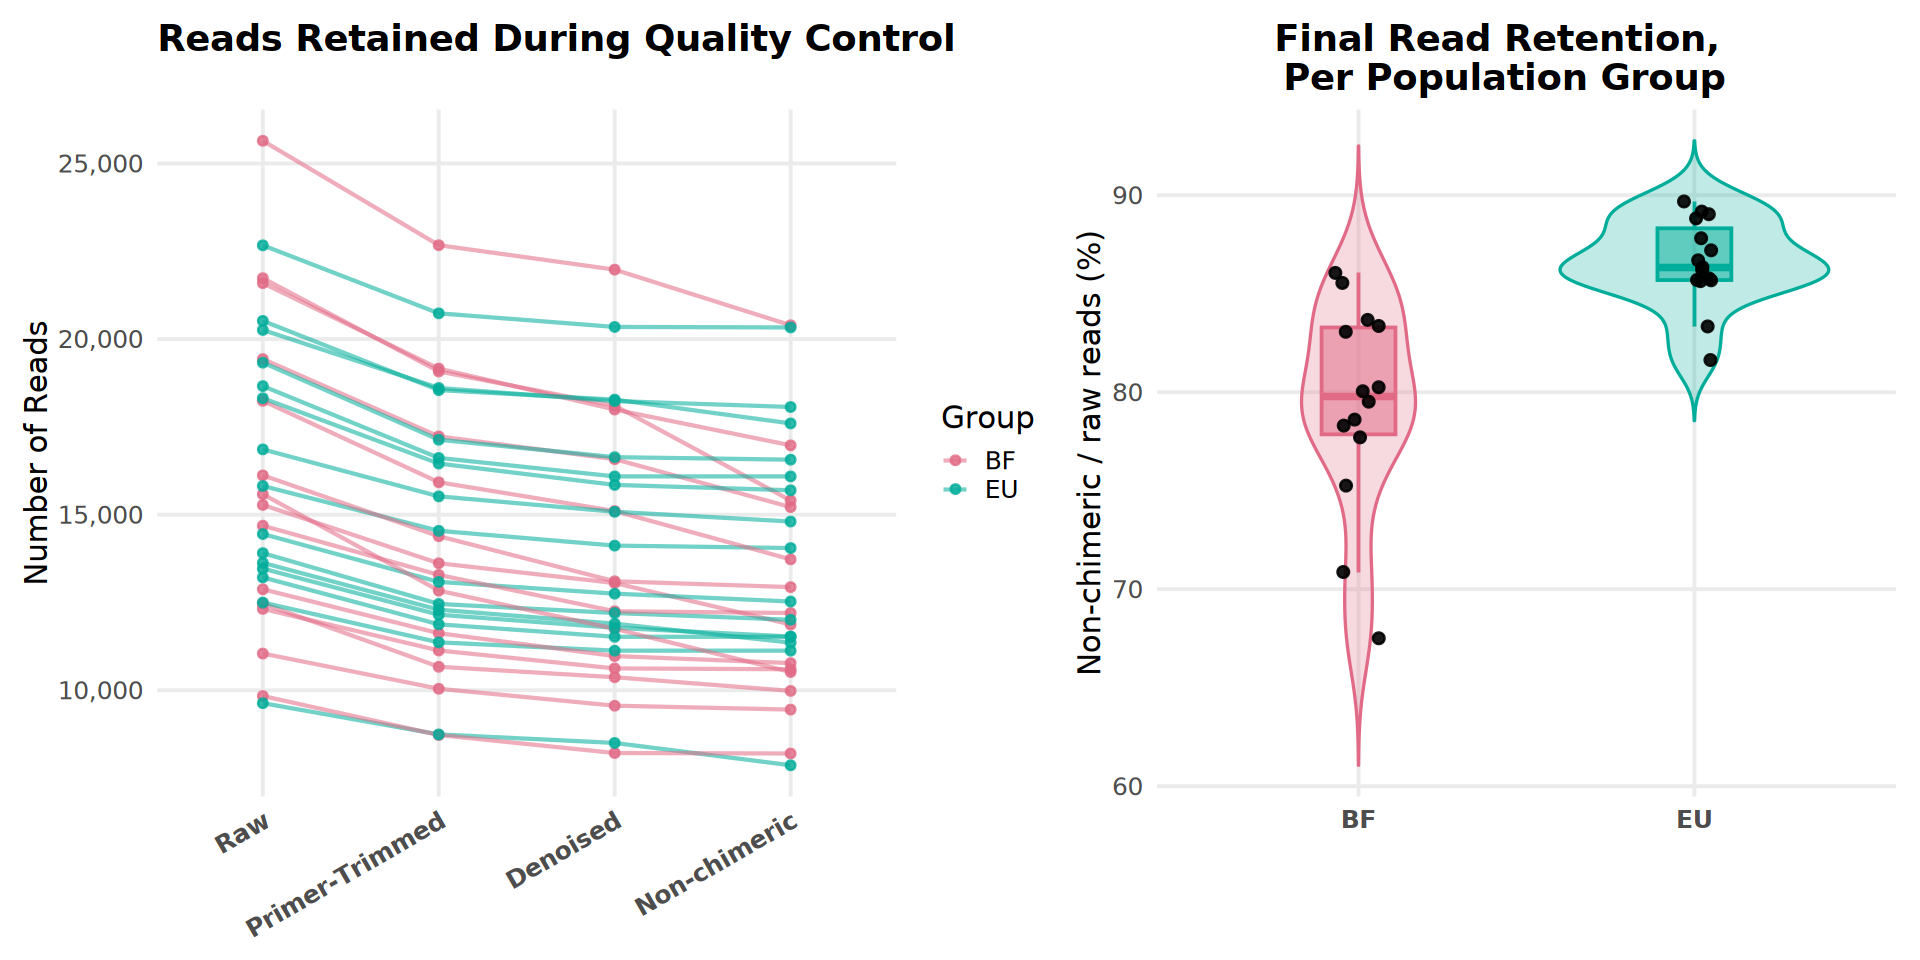

In [33]:
options(repr.plot.width = 16, repr.plot.height = 8)
pA <- qc_fig1a + qc_fig1b
pA

In [35]:
# save figure
ggsave(
    filename = paste0(FIG_QC_DIR, '/', PROJECT_NAME, '.qc_read_retention.png'),
    plot = pA,
    width = 16,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_QC_DIR, '/', PROJECT_NAME, '.qc_read_retention.pdf'),
    plot = pA,
    width = 16,
    height = 8,
    units = "in",
    bg = "white"
)
# save table for making figure in quarto report

write_tsv( 
    qc_long,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".Read_Retention_fig1a.qc_long.tsv")),
    quote = "needed"
)

write_tsv( 
    qc_retention,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".Read_Retention_fig1b.qc_retention.tsv")),
    quote = "needed"
)





